In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pip install pyspark


In [4]:
!pip install xgboost


In [5]:
import pyspark
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('Dataframe').getOrCreate()

In [6]:
spark


In [7]:
df=spark.read.csv('/content/drive/MyDrive/Dataset/pubg.csv',header=True,inferSchema=True)


In [8]:
df.printSchema()


root
 |-- Id: string (nullable = true)
 |-- groupId: string (nullable = true)
 |-- matchId: string (nullable = true)
 |-- assists: integer (nullable = true)
 |-- boosts: integer (nullable = true)
 |-- damageDealt: double (nullable = true)
 |-- DBNOs: integer (nullable = true)
 |-- headshotKills: integer (nullable = true)
 |-- heals: integer (nullable = true)
 |-- killPlace: integer (nullable = true)
 |-- killPoints: integer (nullable = true)
 |-- kills: integer (nullable = true)
 |-- killStreaks: integer (nullable = true)
 |-- longestKill: double (nullable = true)
 |-- matchDuration: integer (nullable = true)
 |-- matchType: string (nullable = true)
 |-- maxPlace: integer (nullable = true)
 |-- numGroups: integer (nullable = true)
 |-- rankPoints: integer (nullable = true)
 |-- revives: integer (nullable = true)
 |-- rideDistance: double (nullable = true)
 |-- roadKills: integer (nullable = true)
 |-- swimDistance: double (nullable = true)
 |-- teamKills: integer (nullable = true)
 |--

In [9]:
type(df)


pyspark.sql.dataframe.DataFrame

In [10]:
df.head(5)


[Row(Id='7f96b2f878858a', groupId='4d4b580de459be', matchId='a10357fd1a4a91', assists=0, boosts=0, damageDealt=0.0, DBNOs=0, headshotKills=0, heals=0, killPlace=60, killPoints=1241, kills=0, killStreaks=0, longestKill=0.0, matchDuration=1306, matchType='squad-fpp', maxPlace=28, numGroups=26, rankPoints=-1, revives=0, rideDistance=0.0, roadKills=0, swimDistance=0.0, teamKills=0, vehicleDestroys=0, walkDistance=244.8, weaponsAcquired=1, winPoints=1466, winPlacePerc=0.4444),
 Row(Id='eef90569b9d03c', groupId='684d5656442f9e', matchId='aeb375fc57110c', assists=0, boosts=0, damageDealt=91.47, DBNOs=0, headshotKills=0, heals=0, killPlace=57, killPoints=0, kills=0, killStreaks=0, longestKill=0.0, matchDuration=1777, matchType='squad-fpp', maxPlace=26, numGroups=25, rankPoints=1484, revives=0, rideDistance=0.0045, roadKills=0, swimDistance=11.04, teamKills=0, vehicleDestroys=0, walkDistance=1434.0, weaponsAcquired=5, winPoints=0, winPlacePerc=0.64),
 Row(Id='1eaf90ac73de72', groupId='6a4a42c32

In [11]:
df.describe().show()


+-------+--------------+--------------+--------------+-------------------+------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+---------+------------------+------------------+-----------------+-------------------+------------------+--------------------+-----------------+-------------------+-------------------+------------------+------------------+-----------------+-------------------+
|summary|            Id|       groupId|       matchId|            assists|            boosts|       damageDealt|             DBNOs|      headshotKills|             heals|         killPlace|        killPoints|             kills|       killStreaks|      longestKill|     matchDuration|matchType|          maxPlace|         numGroups|       rankPoints|            revives|      rideDistance|           roadKills|     swimDistance|          teamKills|    vehic

In [12]:
  # Sample the data
  # Example: % sample, without replacement

  fraction = 0.01
  sampled_data = df.sample(withReplacement=False, fraction=fraction, seed=42)

  # Convert to Pandas DataFrame
  pandas_df = sampled_data.toPandas()



In [13]:
print(pandas_df.columns)  # Print the columns of pandas_df


Index(['Id', 'groupId', 'matchId', 'assists', 'boosts', 'damageDealt', 'DBNOs',
       'headshotKills', 'heals', 'killPlace', 'killPoints', 'kills',
       'killStreaks', 'longestKill', 'matchDuration', 'matchType', 'maxPlace',
       'numGroups', 'rankPoints', 'revives', 'rideDistance', 'roadKills',
       'swimDistance', 'teamKills', 'vehicleDestroys', 'walkDistance',
       'weaponsAcquired', 'winPoints', 'winPlacePerc'],
      dtype='object')


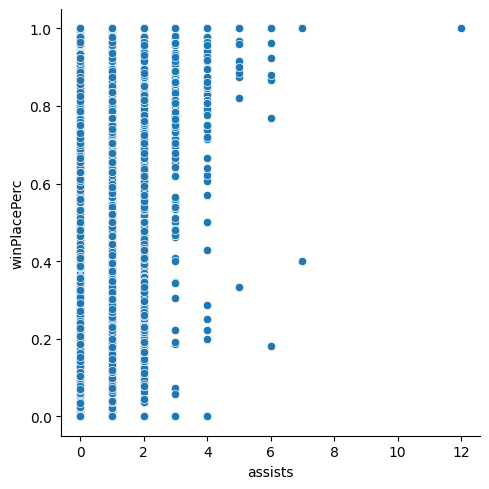

In [14]:
sns.relplot(x='assists', y='winPlacePerc', data=pandas_df)
plt.show()

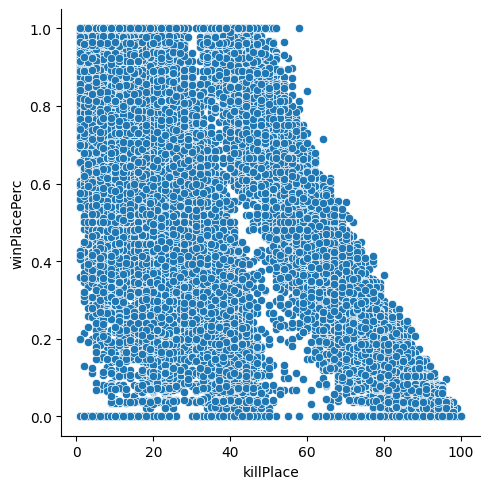

In [15]:
sns.relplot(x='killPlace',y='winPlacePerc',data=pandas_df)
# killPlace are not showing much trend for the winPlacePerc.

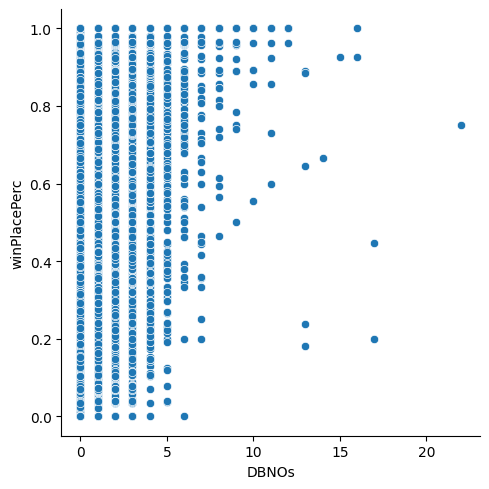

In [16]:

# Analyzing assists and winPlacePerc
sns.relplot(x='DBNOs',y='winPlacePerc',data=pandas_df)
# killPlace are showing trend for the winPlacePerc.

In [17]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("YourAppName") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()


In [18]:
from pyspark.sql.functions import count, when, col
# Get the column names from the DataFrame
columns_to_check = ['assists', 'boosts', 'damageDealt', 'DBNOs', 'headshotKills', 'heals', 'killPlace', 'killPoints', 'kills', 'killStreaks', 'longestKill', 'matchDuration', 'maxPlace', 'numGroups', 'rankPoints', 'revives', 'rideDistance', 'roadKills', 'swimDistance', 'teamKills', 'vehicleDestroys', 'walkDistance', 'weaponsAcquired', 'winPoints', 'winPlacePerc', 'matchType']

null_counts = df.select([count(when(col(c).isNull(), c)).alias(c) for c in columns_to_check])

# Show the results
null_counts.show()

+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+------------+---------+
|assists|boosts|damageDealt|DBNOs|headshotKills|heals|killPlace|killPoints|kills|killStreaks|longestKill|matchDuration|maxPlace|numGroups|rankPoints|revives|rideDistance|roadKills|swimDistance|teamKills|vehicleDestroys|walkDistance|weaponsAcquired|winPoints|winPlacePerc|matchType|
+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+------------+---------+
|      0|     0|          0|    0|            0|    0|        0|         0|    0|          0|          0|            0|       0|        0|         0|     

In [19]:
# prompt: how to clear the null value in column winPlaceprec

from pyspark.sql.functions import when, count, col, mean

# Calculate the mean of 'winPlacePerc'
mean_winPlacePerc = df.select(mean(col('winPlacePerc'))).collect()[0][0]

# Fill null values in 'winPlacePerc' with the mean
df = df.fillna(mean_winPlacePerc, subset=['winPlacePerc'])

# Verify the null counts again
null_counts = df.select([count(when(col(c).isNull(), c)).alias(c) for c in columns_to_check])
null_counts.show()


+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+------------+---------+
|assists|boosts|damageDealt|DBNOs|headshotKills|heals|killPlace|killPoints|kills|killStreaks|longestKill|matchDuration|maxPlace|numGroups|rankPoints|revives|rideDistance|roadKills|swimDistance|teamKills|vehicleDestroys|walkDistance|weaponsAcquired|winPoints|winPlacePerc|matchType|
+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+------------+---------+
|      0|     0|          0|    0|            0|    0|        0|         0|    0|          0|          0|            0|       0|        0|         0|     

In [20]:
from pyspark.ml.feature import StringIndexer
indexer=StringIndexer(inputCol="matchType",outputCol="matchType_")
df=indexer.fit(df).transform(df)
df.show()

+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+------------+----------+
|            Id|       groupId|       matchId|assists|boosts|damageDealt|DBNOs|headshotKills|heals|killPlace|killPoints|kills|killStreaks|longestKill|matchDuration|matchType|maxPlace|numGroups|rankPoints|revives|rideDistance|roadKills|swimDistance|teamKills|vehicleDestroys|walkDistance|weaponsAcquired|winPoints|winPlacePerc|matchType_|
+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+-----------

In [21]:
# prompt: i want to delete and drop first 3 column

# Get the first 3 column names
columns_to_drop = df.columns[:3]

# Drop the columns
pandas_df = df.drop('Id','groupId','matchId','matchType')

# Show the updated DataFrame
pandas_df.show()



+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+------------+----------+
|assists|boosts|damageDealt|DBNOs|headshotKills|heals|killPlace|killPoints|kills|killStreaks|longestKill|matchDuration|maxPlace|numGroups|rankPoints|revives|rideDistance|roadKills|swimDistance|teamKills|vehicleDestroys|walkDistance|weaponsAcquired|winPoints|winPlacePerc|matchType_|
+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+------------+----------+
|      0|     0|        0.0|    0|            0|    0|       60|      1241|    0|          0|        0.0|         1306|      28|       26|        -1|  

In [22]:
pandas_df = df.drop('matchType')
pandas_df.show()


+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+------------+----------+
|            Id|       groupId|       matchId|assists|boosts|damageDealt|DBNOs|headshotKills|heals|killPlace|killPoints|kills|killStreaks|longestKill|matchDuration|maxPlace|numGroups|rankPoints|revives|rideDistance|roadKills|swimDistance|teamKills|vehicleDestroys|walkDistance|weaponsAcquired|winPoints|winPlacePerc|matchType_|
+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+------------+----------+
|7f96b2f878858a|

In [23]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Assuming df is your dataframe and the column to check is 'column_name'
column_name = df['assists']

# Calculate the mean and standard deviation of the column
mean_val = df.select(F.mean(F.col('assists'))).first()[0]
stddev_val = df.select(F.stddev(F.col('assists'))).first()[0]

# Calculate the Z-score for each row
df_with_zscore = df.withColumn('zscore', (F.col('assists') - mean_val) / stddev_val)

# Define a threshold for identifying outliers (commonly 3)
threshold = 3

# Separate outliers based on the Z-score
outliers = df_with_zscore.filter(F.abs(F.col('zscore')) > threshold)

# Separate the non-outliers
non_outliers = df_with_zscore.filter(F.abs(F.col('zscore')) <= threshold)

# Show results
outliers.show()
non_outliers.show()


+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+------------+----------+------------------+
|            Id|       groupId|       matchId|assists|boosts|damageDealt|DBNOs|headshotKills|heals|killPlace|killPoints|kills|killStreaks|longestKill|matchDuration|matchType|maxPlace|numGroups|rankPoints|revives|rideDistance|roadKills|swimDistance|teamKills|vehicleDestroys|walkDistance|weaponsAcquired|winPoints|winPlacePerc|matchType_|            zscore|
+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------

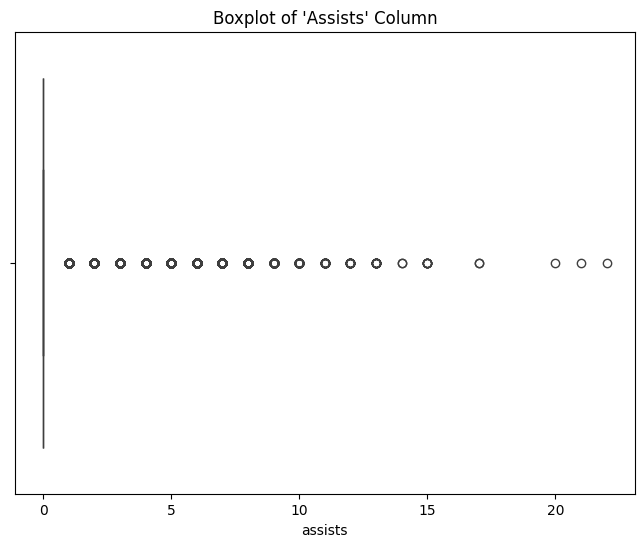

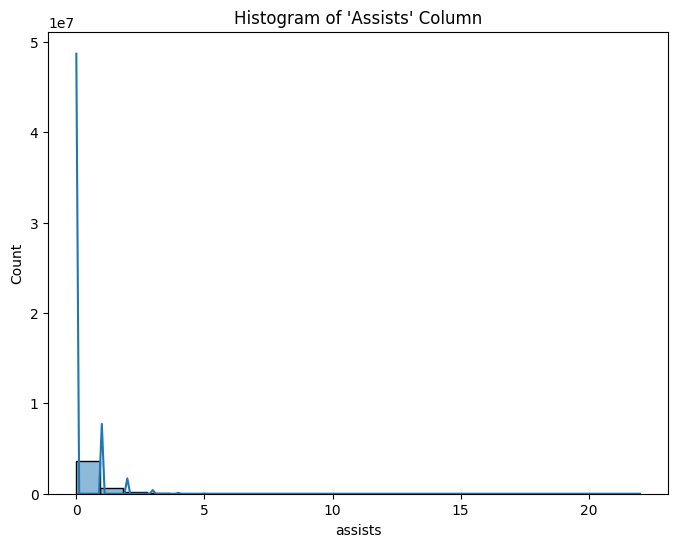

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your PySpark DataFrame
# Convert the "assists" column to a Pandas DataFrame for visualization
assists_df = df.select('assists').toPandas()

# Create a boxplot to visualize outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=assists_df['assists'])
plt.title("Boxplot of 'Assists' Column")
plt.show()

# Optionally, create a histogram to visualize the distribution
plt.figure(figsize=(8, 6))
sns.histplot(assists_df['assists'], kde=True)
plt.title("Histogram of 'Assists' Column")
plt.show()


In [25]:
from pyspark.sql import functions as F

# Assuming df is your DataFrame and you want to clean the "assists" column

# Set the Z-score threshold (commonly 3)
threshold = 3

# Calculate the mean and standard deviation of the "assists" column
mean_assists = df.select(F.mean(F.col('assists'))).first()[0]
stddev_assists = df.select(F.stddev(F.col('assists'))).first()[0]

# Calculate the Z-score for each row in the "assists" column
df_with_zscore = df.withColumn('zscore_assists', (F.col('assists') - mean_assists) / stddev_assists)

# Filter rows where the absolute Z-score is less than or equal to the threshold (no outliers)
df_cleaned = df_with_zscore.filter(F.abs(F.col('zscore_assists')) <= threshold)

# Show the cleaned DataFrame
df_cleaned.show()


+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+------------+----------+--------------------+
|            Id|       groupId|       matchId|assists|boosts|damageDealt|DBNOs|headshotKills|heals|killPlace|killPoints|kills|killStreaks|longestKill|matchDuration|matchType|maxPlace|numGroups|rankPoints|revives|rideDistance|roadKills|swimDistance|teamKills|vehicleDestroys|walkDistance|weaponsAcquired|winPoints|winPlacePerc|matchType_|      zscore_assists|
+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+--------

In [26]:
df_cleaned.describe('assists').show()


+-------+-------------------+
|summary|            assists|
+-------+-------------------+
|  count|            4259543|
|   mean|0.13895457799111313|
| stddev|0.34589916353672895|
|    min|                  0|
|    max|                  1|
+-------+-------------------+



In [27]:
from pyspark.sql import functions as F

# Assuming df is your PySpark DataFrame and you want to check the outliers in the "assists" column
threshold = 3  # Z-score threshold to identify outliers

# Calculate the mean and standard deviation of the "assists" column
mean_assists = df.select(F.mean(F.col('assists'))).first()[0]
stddev_assists = df.select(F.stddev(F.col('assists'))).first()[0]

# Calculate the upper and lower bounds
lower_bound = mean_assists - (threshold * stddev_assists)
upper_bound = mean_assists + (threshold * stddev_assists)

# Print the calculated bounds
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")


Lower Bound: -1.5319043414949076
Upper Bound: 1.9995341817050643


In [28]:
df_cleaned = df.filter((F.col('assists') >= lower_bound) & (F.col('assists') <= upper_bound))
df_cleaned.show()


+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+------------+----------+
|            Id|       groupId|       matchId|assists|boosts|damageDealt|DBNOs|headshotKills|heals|killPlace|killPoints|kills|killStreaks|longestKill|matchDuration|matchType|maxPlace|numGroups|rankPoints|revives|rideDistance|roadKills|swimDistance|teamKills|vehicleDestroys|walkDistance|weaponsAcquired|winPoints|winPlacePerc|matchType_|
+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+-----------

In [29]:
df_cleaned = df.filter((F.col('assists') >= 0) & (F.col('assists') <= 1))
df_cleaned.show()



+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+------------+----------+
|            Id|       groupId|       matchId|assists|boosts|damageDealt|DBNOs|headshotKills|heals|killPlace|killPoints|kills|killStreaks|longestKill|matchDuration|matchType|maxPlace|numGroups|rankPoints|revives|rideDistance|roadKills|swimDistance|teamKills|vehicleDestroys|walkDistance|weaponsAcquired|winPoints|winPlacePerc|matchType_|
+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+-----------

In [30]:
df_cleaned.describe('assists').show()


+-------+-------------------+
|summary|            assists|
+-------+-------------------+
|  count|            4259543|
|   mean|0.13895457799111313|
| stddev|0.34589916353672895|
|    min|                  0|
|    max|                  1|
+-------+-------------------+



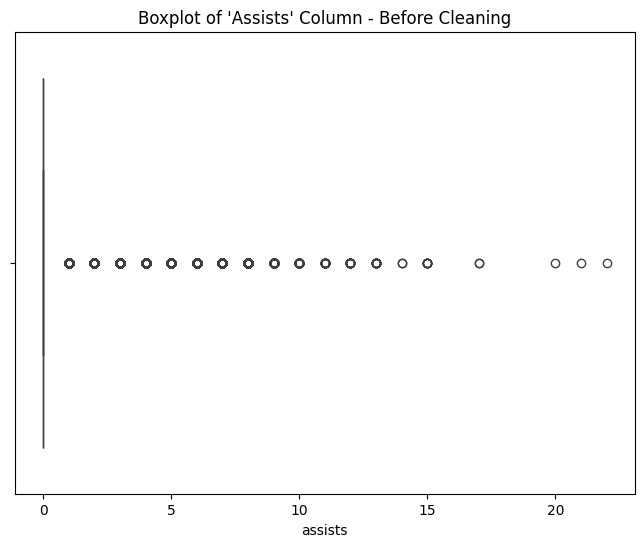

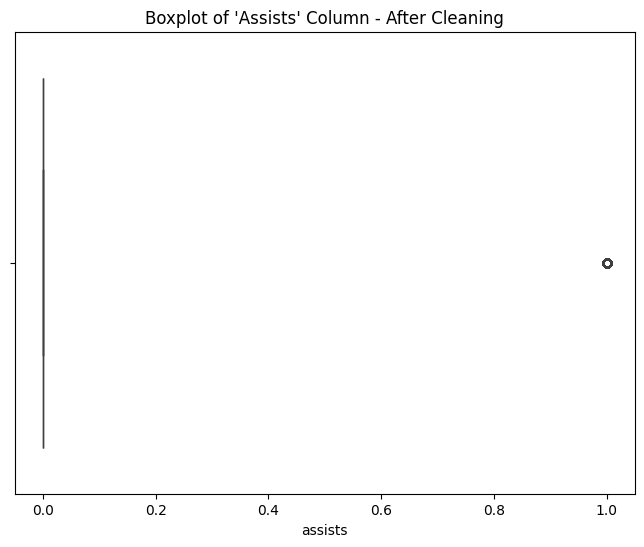

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is the original DataFrame and df_cleaned is the cleaned DataFrame
# Convert the "assists" column to Pandas DataFrame for visualization
assists_df = df.select('assists').toPandas()
assists_cleaned_df = df_cleaned.select('assists').toPandas()

# Create a boxplot to visualize the "assists" column before cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=assists_df['assists'])
plt.title("Boxplot of 'Assists' Column - Before Cleaning")
plt.show()

# Create a boxplot to visualize the "assists" column after cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=assists_cleaned_df['assists'])
plt.title("Boxplot of 'Assists' Column - After Cleaning")
plt.show()


In [32]:
df.describe('boosts').show()


+-------+------------------+
|summary|            boosts|
+-------+------------------+
|  count|           4446966|
|   mean|1.1069077209045448|
| stddev|1.7157936773815516|
|    min|                 0|
|    max|                33|
+-------+------------------+



In [33]:
df.describe('damageDealt').show()


+-------+------------------+
|summary|       damageDealt|
+-------+------------------+
|  count|           4446966|
|   mean|130.71713789840132|
| stddev|170.78062066696396|
|    min|               0.0|
|    max|            6616.0|
+-------+------------------+



In [34]:
from pyspark.sql import functions as F

# Given statistics for "damageDealt" column
mean_damageDealt = 130.7171378984221
stddev_damageDealt = 170.78062066696378
threshold = 3  # Z-score threshold for outliers

# Step 1: Calculate the lower and upper bounds for outliers
lower_bound_damageDealt = mean_damageDealt - (threshold * stddev_damageDealt)
upper_bound_damageDealt = mean_damageDealt + (threshold * stddev_damageDealt)

# Print the calculated bounds
print(f"Lower Bound: {lower_bound_damageDealt}")
print(f"Upper Bound: {upper_bound_damageDealt}")

# Step 2: Filter out rows where "damageDealt" is outside the bounds (outliers)
df_cleaned_damageDealt = df.filter((F.col('damageDealt') >= lower_bound_damageDealt) & (F.col('damageDealt') <= upper_bound_damageDealt))

# Show the cleaned DataFrame (with outliers removed)
df_cleaned_damageDealt.show()


Lower Bound: -381.6247241024692
Upper Bound: 643.0589998993134
+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+------------+----------+
|            Id|       groupId|       matchId|assists|boosts|damageDealt|DBNOs|headshotKills|heals|killPlace|killPoints|kills|killStreaks|longestKill|matchDuration|matchType|maxPlace|numGroups|rankPoints|revives|rideDistance|roadKills|swimDistance|teamKills|vehicleDestroys|walkDistance|weaponsAcquired|winPoints|winPlacePerc|matchType_|
+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+---

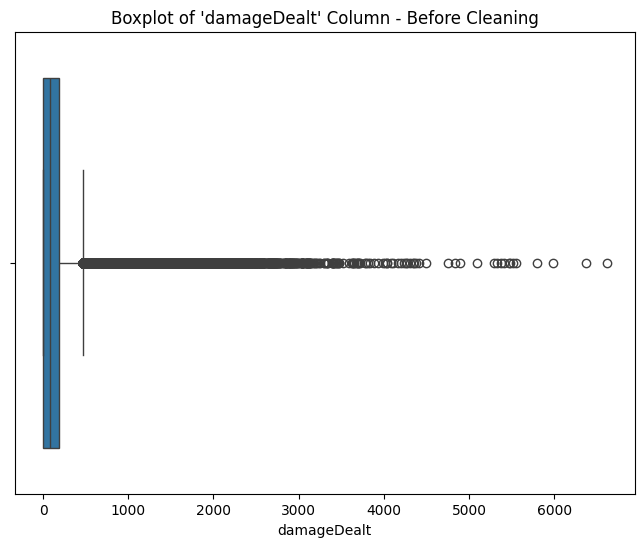

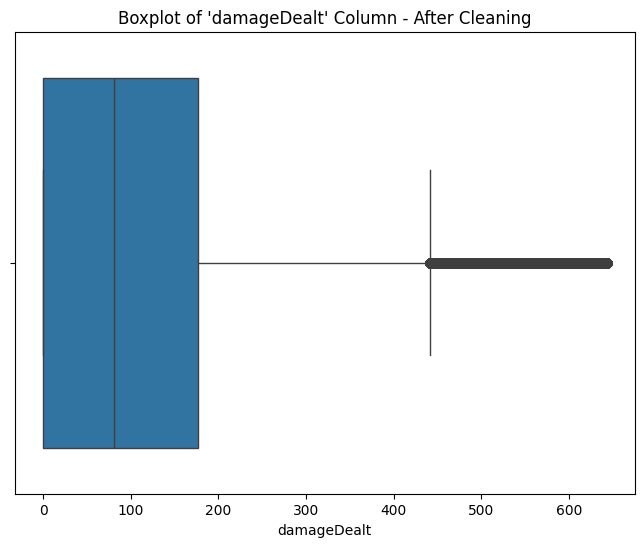

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the original "damageDealt" column to Pandas DataFrame for visualization
damageDealt_df = df.select('damageDealt').toPandas()
damageDealt_cleaned_df = df_cleaned_damageDealt.select('damageDealt').toPandas()

# Create a boxplot to visualize the "damageDealt" column before cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=damageDealt_df['damageDealt'])
plt.title("Boxplot of 'damageDealt' Column - Before Cleaning")
plt.show()

# Create a boxplot to visualize the "damageDealt" column after cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=damageDealt_cleaned_df['damageDealt'])
plt.title("Boxplot of 'damageDealt' Column - After Cleaning")
plt.show()


In [36]:
df.describe('DBNOs').show()


+-------+------------------+
|summary|             DBNOs|
+-------+------------------+
|  count|           4446966|
|   mean|0.6578755043326169|
| stddev|1.1457427249005612|
|    min|                 0|
|    max|                53|
+-------+------------------+



In [37]:
from pyspark.sql import functions as F

# Given statistics for "DBNOs" column
mean_DBNOs = 0.6578755043326169
stddev_DBNOs = 1.145742724900561
threshold = 3  # Z-score threshold for outliers

# Step 1: Calculate the lower and upper bounds for outliers
lower_bound_DBNOs = mean_DBNOs - (threshold * stddev_DBNOs)
upper_bound_DBNOs = mean_DBNOs + (threshold * stddev_DBNOs)

# Print the calculated bounds
print(f"Lower Bound: {lower_bound_DBNOs}")
print(f"Upper Bound: {upper_bound_DBNOs}")

# Step 2: Filter out rows where "DBNOs" is outside the bounds (outliers)
df_cleaned_DBNOs = df.filter((F.col('DBNOs') >= lower_bound_DBNOs) & (F.col('DBNOs') <= upper_bound_DBNOs))

# Show the cleaned DataFrame (with outliers removed)
df_cleaned_DBNOs.show()


Lower Bound: -2.779352670369066
Upper Bound: 4.0951036790343
+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+------------+----------+
|            Id|       groupId|       matchId|assists|boosts|damageDealt|DBNOs|headshotKills|heals|killPlace|killPoints|kills|killStreaks|longestKill|matchDuration|matchType|maxPlace|numGroups|rankPoints|revives|rideDistance|roadKills|swimDistance|teamKills|vehicleDestroys|walkDistance|weaponsAcquired|winPoints|winPlacePerc|matchType_|
+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+-----

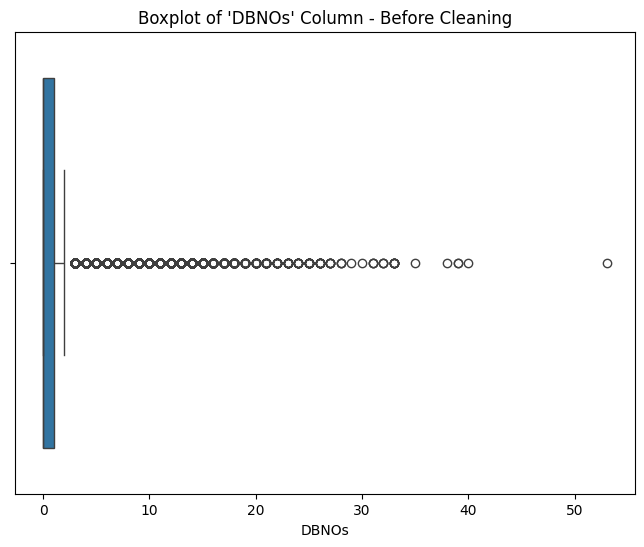

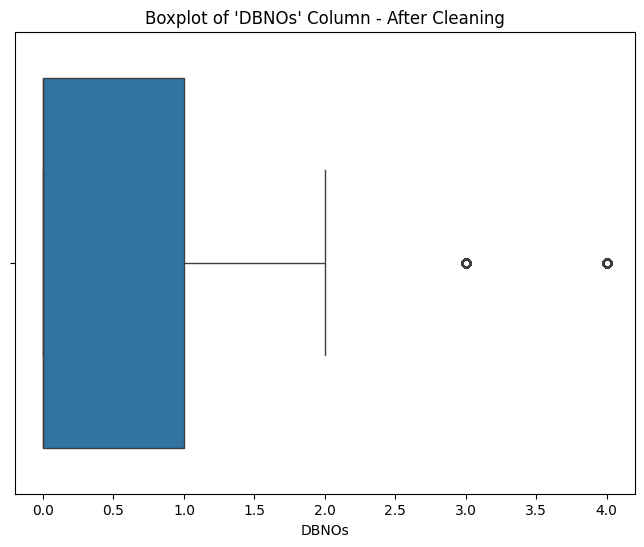

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the original "DBNOs" column to Pandas DataFrame for visualization
DBNOs_df = df.select('DBNOs').toPandas()
DBNOs_cleaned_df = df_cleaned_DBNOs.select('DBNOs').toPandas()

# Create a boxplot to visualize the "DBNOs" column before cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=DBNOs_df['DBNOs'])
plt.title("Boxplot of 'DBNOs' Column - Before Cleaning")
plt.show()

# Create a boxplot to visualize the "DBNOs" column after cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=DBNOs_cleaned_df['DBNOs'])
plt.title("Boxplot of 'DBNOs' Column - After Cleaning")
plt.show()


In [39]:
df.describe('heals').show()


+-------+------------------+
|summary|             heals|
+-------+------------------+
|  count|           4446966|
|   mean| 1.370147196987789|
| stddev|2.6799822305289855|
|    min|                 0|
|    max|                80|
+-------+------------------+



In [40]:
from pyspark.sql import functions as F

# Given statistics for "heals" column
mean_heals = 1.370147196987789
stddev_heals = 2.6799822305289713
threshold = 3  # Z-score threshold for outliers

# Step 1: Calculate the lower and upper bounds for outliers
lower_bound_heals = mean_heals - (threshold * stddev_heals)
upper_bound_heals = mean_heals + (threshold * stddev_heals)

# Print the calculated bounds
print(f"Lower Bound: {lower_bound_heals}")
print(f"Upper Bound: {upper_bound_heals}")

# Step 2: Filter out rows where "heals" is outside the bounds (outliers)
df_cleaned_heals = df.filter((F.col('heals') >= lower_bound_heals) & (F.col('heals') <= upper_bound_heals))

# Show the cleaned DataFrame (with outliers removed)
df_cleaned_heals.show()


Lower Bound: -6.6697994945991255
Upper Bound: 9.410093888574703
+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+------------+----------+
|            Id|       groupId|       matchId|assists|boosts|damageDealt|DBNOs|headshotKills|heals|killPlace|killPoints|kills|killStreaks|longestKill|matchDuration|matchType|maxPlace|numGroups|rankPoints|revives|rideDistance|roadKills|swimDistance|teamKills|vehicleDestroys|walkDistance|weaponsAcquired|winPoints|winPlacePerc|matchType_|
+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+--

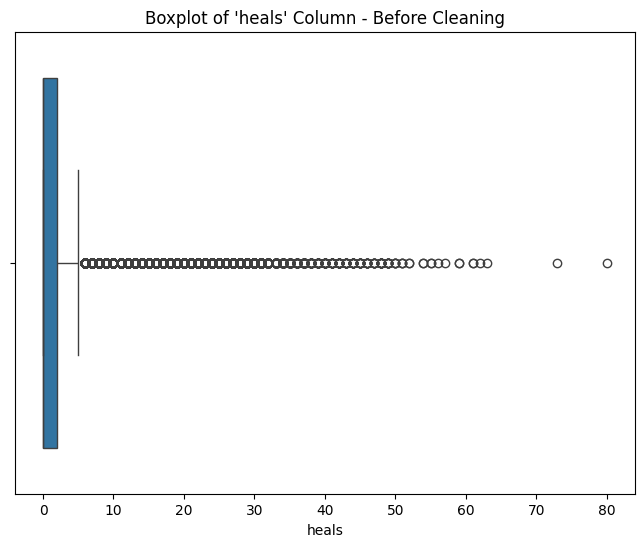

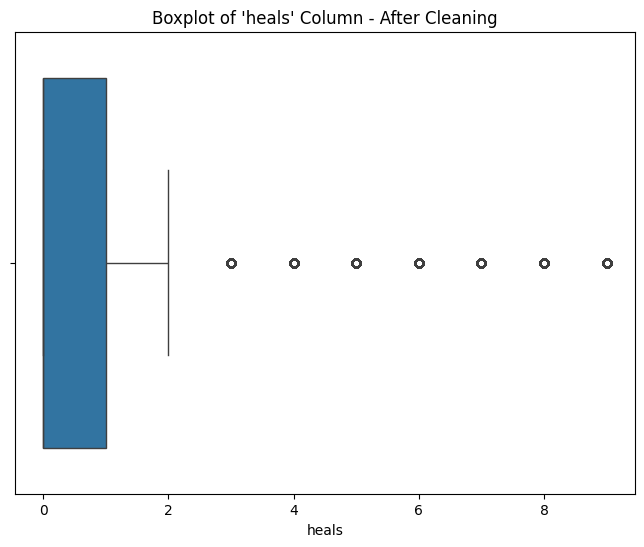

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the original "heals" column to Pandas DataFrame for visualization
heals_df = df.select('heals').toPandas()
heals_cleaned_df = df_cleaned_heals.select('heals').toPandas()

# Create a boxplot to visualize the "heals" column before cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=heals_df['heals'])
plt.title("Boxplot of 'heals' Column - Before Cleaning")
plt.show()

# Create a boxplot to visualize the "heals" column after cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=heals_cleaned_df['heals'])
plt.title("Boxplot of 'heals' Column - After Cleaning")
plt.show()


In [42]:
def handle_outliers_iqr(df, boosts):

    # Calculate quartiles and IQR
    quartiles = df.approxQuantile(boosts, [0.25, 0.75], 0.01)
    q1 = quartiles[0]
    q3 = quartiles[1]
    iqr = q3 - q1

    # Define outlier bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Calculate the median
    median = df.approxQuantile(boosts, [0.5], 0.01)[0]

    # Impute outliers with the median
    df_imputed = df.withColumn(
        boosts,
        F.when(
            (F.col(boosts) < lower_bound) | (F.col(boosts) > upper_bound),
            F.lit(median)
        ).otherwise(F.col(boosts))
    )

    return df_imputed

<Axes: xlabel='boosts'>

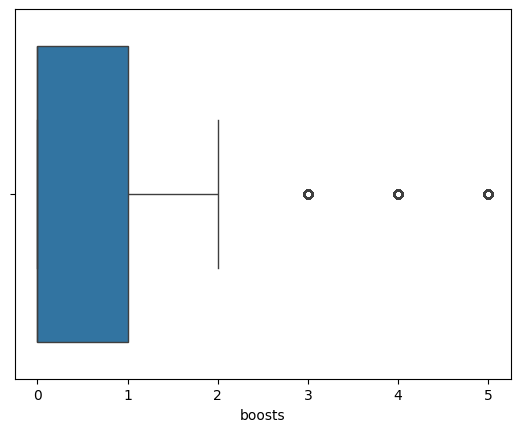

In [43]:
df = handle_outliers_iqr(df, "boosts")
boosts_df = df.select('boosts').toPandas()
sns.boxplot(x='boosts', data=boosts_df)

In [44]:
df.describe('killStreaks').show()


+-------+------------------+
|summary|       killStreaks|
+-------+------------------+
|  count|           4446966|
|   mean| 0.543955137052993|
| stddev|0.7109720924089302|
|    min|                 0|
|    max|                20|
+-------+------------------+



In [45]:
from pyspark.sql import functions as F

# Given statistics for "killStreaks" column
mean_killStreaks = 0.543955137052993
stddev_killStreaks = 0.7109720924089302
threshold = 3  # Z-score threshold for outliers

# Step 1: Calculate the lower and upper bounds for outliers
lower_bound_killStreaks = mean_killStreaks - (threshold * stddev_killStreaks)
upper_bound_killStreaks = mean_killStreaks + (threshold * stddev_killStreaks)

# Print the calculated bounds
print(f"Lower Bound: {lower_bound_killStreaks}")
print(f"Upper Bound: {upper_bound_killStreaks}")

# Step 2: Filter out rows where "killStreaks" is outside the bounds (outliers)
df_cleaned_killStreaks = df.filter((F.col('killStreaks') >= lower_bound_killStreaks) & (F.col('killStreaks') <= upper_bound_killStreaks))

# Show the cleaned DataFrame (with outliers removed)
df_cleaned_killStreaks.show()


Lower Bound: -1.5889611401737977
Upper Bound: 2.6768714142797836
+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+---------------+------------+---------------+---------+------------+----------+
|            Id|       groupId|       matchId|assists|boosts|damageDealt|DBNOs|headshotKills|heals|killPlace|killPoints|kills|killStreaks|longestKill|matchDuration|matchType|maxPlace|numGroups|rankPoints|revives|rideDistance|roadKills|swimDistance|teamKills|vehicleDestroys|walkDistance|weaponsAcquired|winPoints|winPlacePerc|matchType_|
+--------------+--------------+--------------+-------+------+-----------+-----+-------------+-----+---------+----------+-----+-----------+-----------+-------------+---------+--------+---------+----------+-------+------------+---------+------------+---------+-

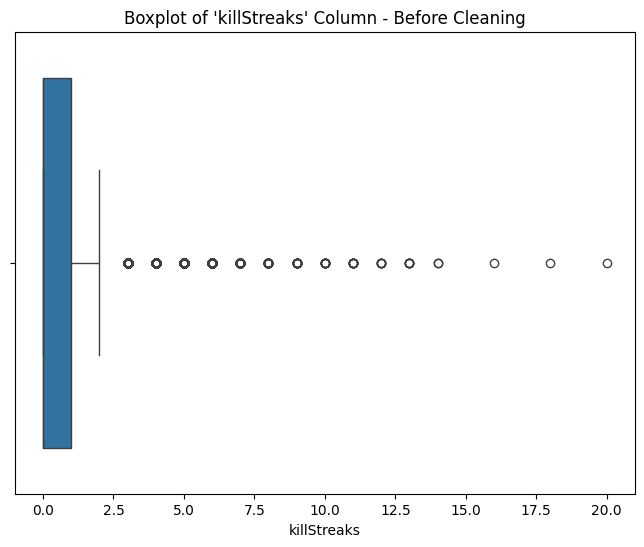

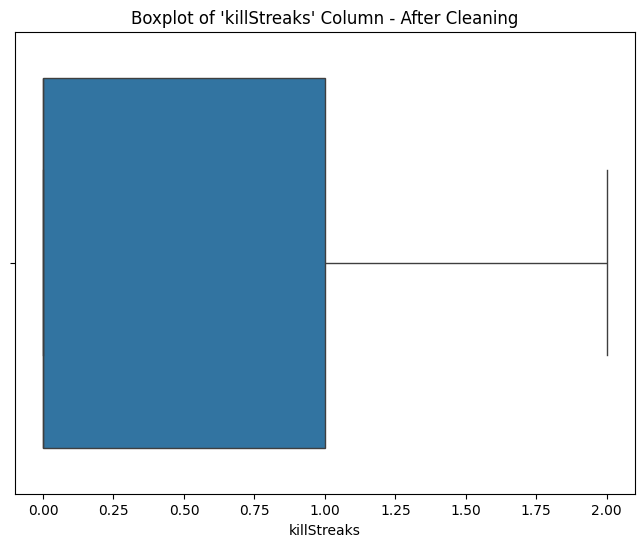

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the original "killStreaks" column to Pandas DataFrame for visualization
killStreaks_df = df.select('killStreaks').toPandas()
killStreaks_cleaned_df = df_cleaned_killStreaks.select('killStreaks').toPandas()

# Create a boxplot to visualize the "killStreaks" column before cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=killStreaks_df['killStreaks'])
plt.title("Boxplot of 'killStreaks' Column - Before Cleaning")
plt.show()

# Create a boxplot to visualize the "killStreaks" column after cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=killStreaks_cleaned_df['killStreaks'])
plt.title("Boxplot of 'killStreaks' Column - After Cleaning")
plt.show()


In [47]:
df.describe('longestKill').show()


+-------+-----------------+
|summary|      longestKill|
+-------+-----------------+
|  count|          4446966|
|   mean|22.99759484533923|
| stddev|50.97261881617954|
|    min|              0.0|
|    max|           1094.0|
+-------+-----------------+



Lower Bound: -129.9202616031994
Upper Bound: 175.91545129387785


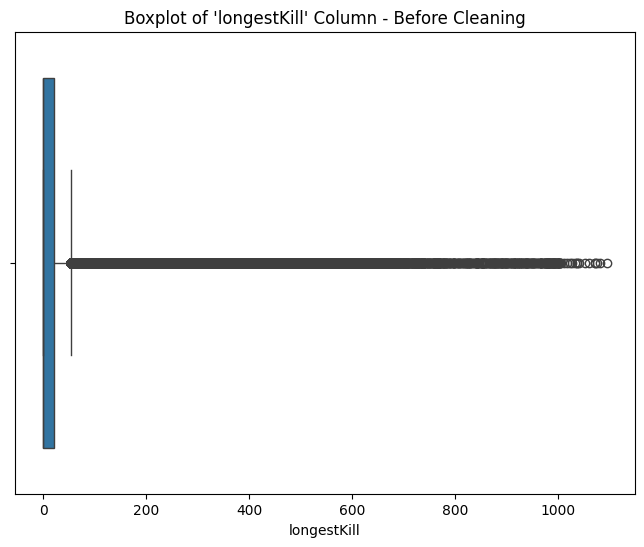

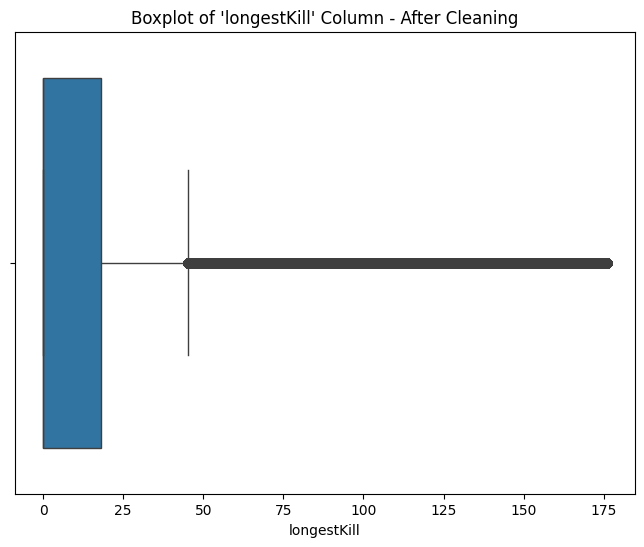

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# Given statistics for "longestKill" column
mean_longestKill = 22.99759484533923
stddev_longestKill = 50.97261881617954
threshold = 3  # Z-score threshold for outliers

# Step 1: Calculate the lower and upper bounds for outliers
lower_bound_longestKill = mean_longestKill - (threshold * stddev_longestKill)
upper_bound_longestKill = mean_longestKill + (threshold * stddev_longestKill)

# Print the calculated bounds
print(f"Lower Bound: {lower_bound_longestKill}")
print(f"Upper Bound: {upper_bound_longestKill}")

# Step 2: Filter out rows where "longestKill" is outside the bounds (outliers)
df_cleaned_longestKill = df.filter(
    (F.col('longestKill') >= lower_bound_longestKill) &
    (F.col('longestKill') <= upper_bound_longestKill)
)

# Convert the original "longestKill" column to Pandas DataFrame for visualization
longestKill_df = df.select('longestKill').toPandas()
longestKill_cleaned_df = df_cleaned_longestKill.select('longestKill').toPandas()

# Create a boxplot to visualize the "longestKill" column before cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=longestKill_df['longestKill'])
plt.title("Boxplot of 'longestKill' Column - Before Cleaning")
plt.show()

# Create a boxplot to visualize the "longestKill" column after cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=longestKill_cleaned_df['longestKill'])
plt.title("Boxplot of 'longestKill' Column - After Cleaning")
plt.show()


In [49]:
df.describe('kills').show()


+-------+------------------+
|summary|             kills|
+-------+------------------+
|  count|           4446966|
|   mean|0.9247833241810259|
| stddev| 1.558444653227703|
|    min|                 0|
|    max|                72|
+-------+------------------+



Lower Bound: -3.7505506355020835
Upper Bound: 5.600117283864135


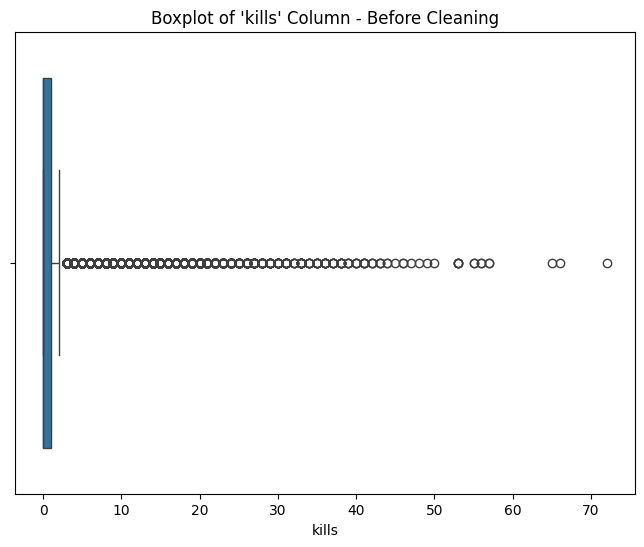

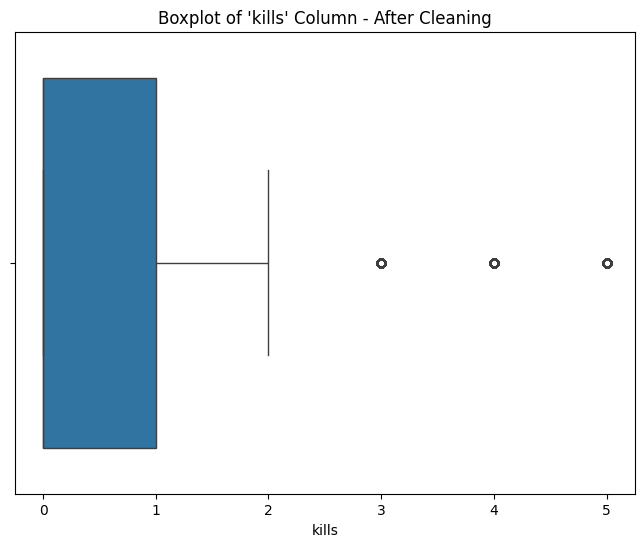

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# Given statistics for "kills" column
mean_kills = 0.9247833241810259
stddev_kills = 1.558444653227703
threshold = 3  # Z-score threshold for outliers

# Step 1: Calculate the lower and upper bounds for outliers
lower_bound_kills = mean_kills - (threshold * stddev_kills)
upper_bound_kills = mean_kills + (threshold * stddev_kills)

# Print the calculated bounds
print(f"Lower Bound: {lower_bound_kills}")
print(f"Upper Bound: {upper_bound_kills}")

# Step 2: Filter out rows where "kills" is outside the bounds (outliers)
df_cleaned_kills = df.filter(
    (F.col('kills') >= lower_bound_kills) &
    (F.col('kills') <= upper_bound_kills)
)

# Convert the original "kills" column to Pandas DataFrame for visualization
kills_df = df.select('kills').toPandas()
kills_cleaned_df = df_cleaned_kills.select('kills').toPandas()

# Create a boxplot to visualize the "kills" column before cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=kills_df['kills'])
plt.title("Boxplot of 'kills' Column - Before Cleaning")
plt.show()

# Create a boxplot to visualize the "kills" column after cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=kills_cleaned_df['kills'])
plt.title("Boxplot of 'kills' Column - After Cleaning")
plt.show()


In [51]:
df.describe('matchDuration').show()


+-------+------------------+
|summary|     matchDuration|
+-------+------------------+
|  count|           4446966|
|   mean|1579.5064396714524|
| stddev|258.73985646079535|
|    min|                 9|
|    max|              2237|
+-------+------------------+



Lower Bound: 803.2868702890664
Upper Bound: 2355.7260090538384


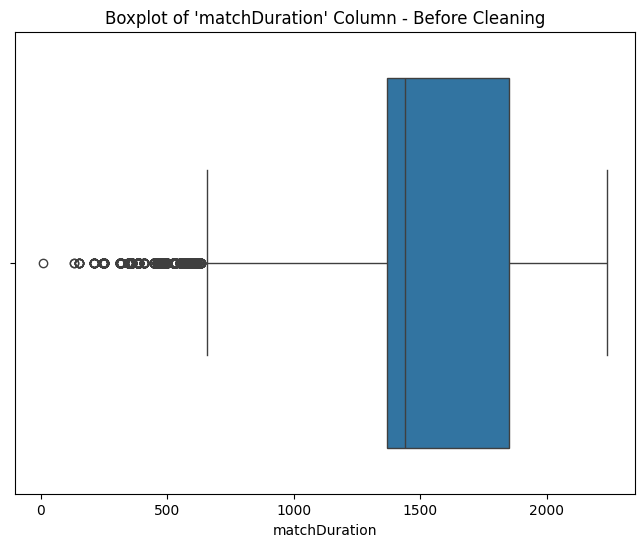

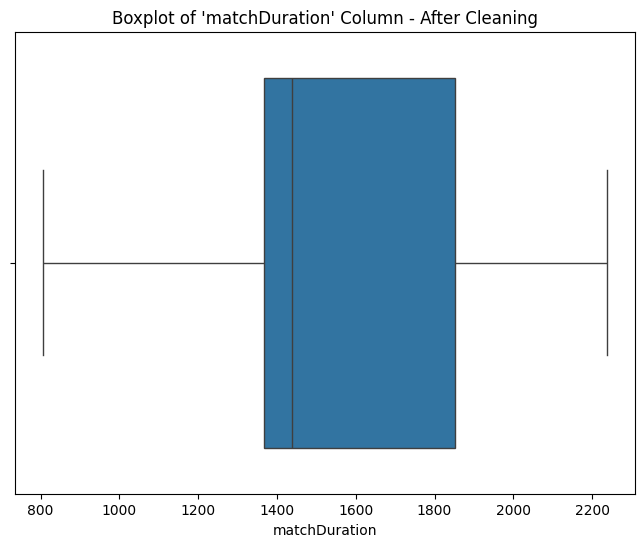

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# Given statistics for "matchDuration" column
mean_matchDuration = 1579.5064396714524
stddev_matchDuration = 258.73985646079535
threshold = 3  # Z-score threshold for outliers

# Step 1: Calculate the lower and upper bounds for outliers
lower_bound_matchDuration = mean_matchDuration - (threshold * stddev_matchDuration)
upper_bound_matchDuration = mean_matchDuration + (threshold * stddev_matchDuration)

# Print the calculated bounds
print(f"Lower Bound: {lower_bound_matchDuration}")
print(f"Upper Bound: {upper_bound_matchDuration}")

# Step 2: Filter out rows where "matchDuration" is outside the bounds (outliers)
df_cleaned_matchDuration = df.filter(
    (F.col('matchDuration') >= lower_bound_matchDuration) &
    (F.col('matchDuration') <= upper_bound_matchDuration)
)

# Convert the original "matchDuration" column to Pandas DataFrame for visualization
matchDuration_df = df.select('matchDuration').toPandas()
matchDuration_cleaned_df = df_cleaned_matchDuration.select('matchDuration').toPandas()

# Create a boxplot to visualize the "matchDuration" column before cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=matchDuration_df['matchDuration'])
plt.title("Boxplot of 'matchDuration' Column - Before Cleaning")
plt.show()

# Create a boxplot to visualize the "matchDuration" column after cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=matchDuration_cleaned_df['matchDuration'])
plt.title("Boxplot of 'matchDuration' Column - After Cleaning")
plt.show()


In [53]:
df.describe('maxPlace').show()


+-------+------------------+
|summary|          maxPlace|
+-------+------------------+
|  count|           4446966|
|   mean|44.504670150390176|
| stddev|23.828105454921836|
|    min|                 1|
|    max|               100|
+-------+------------------+



In [54]:
def handle_outliers_iqr(df, maxPlace):

    # Calculate quartiles and IQR
    quartiles = df.approxQuantile(maxPlace, [0.25, 0.75], 0.01)
    q1 = quartiles[0]
    q3 = quartiles[1]
    iqr = q3 - q1

    # Define outlier bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Calculate the median
    median = df.approxQuantile(maxPlace, [0.5], 0.01)[0]

    # Impute outliers with the median
    df_imputed = df.withColumn(
        maxPlace,
        F.when(
            (F.col(maxPlace) < lower_bound) | (F.col(maxPlace) > upper_bound),
            F.lit(median)
        ).otherwise(F.col(maxPlace))
    )

    return df_imputed

<Axes: xlabel='maxPlace'>

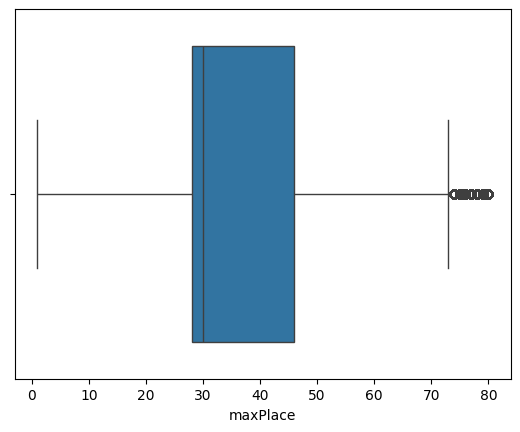

In [55]:
df = handle_outliers_iqr(df, "maxPlace")
maxPlace_df = df.select('maxPlace').toPandas()
sns.boxplot(x='maxPlace', data=maxPlace_df)

In [56]:
df.describe('numGroups').show()


+-------+------------------+
|summary|         numGroups|
+-------+------------------+
|  count|           4446966|
|   mean| 43.00759259234273|
| stddev|23.289494662858477|
|    min|                 1|
|    max|               100|
+-------+------------------+



In [57]:
def handle_outliers_iqr(df, numGroups):

    # Calculate quartiles and IQR
    quartiles = df.approxQuantile(numGroups, [0.25, 0.75], 0.01)
    q1 = quartiles[0]
    q3 = quartiles[1]
    iqr = q3 - q1

    # Define outlier bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Calculate the median
    median = df.approxQuantile(numGroups, [0.5], 0.01)[0]

    # Impute outliers with the median
    df_imputed = df.withColumn(
        numGroups,
        F.when(
            (F.col(numGroups) < lower_bound) | (F.col(numGroups) > upper_bound),
            F.lit(median)
        ).otherwise(F.col(numGroups))
    )

    return df_imputed

<Axes: xlabel='numGroups'>

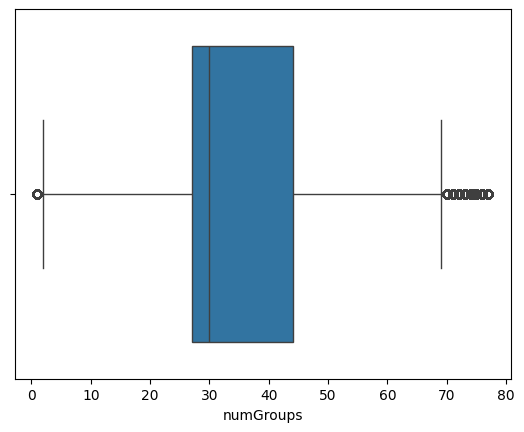

In [58]:
df = handle_outliers_iqr(df, "numGroups")
numGroups_df = df.select('numGroups').toPandas()
sns.boxplot(x='numGroups', data=numGroups_df)

In [59]:
df.describe('rankPoints').show()


+-------+-----------------+
|summary|       rankPoints|
+-------+-----------------+
|  count|          4446966|
|   mean|892.0104565674665|
| stddev|736.6477793343946|
|    min|               -1|
|    max|             5910|
+-------+-----------------+



Lower Bound: -1317.9328814357173
Upper Bound: 3101.95379457065


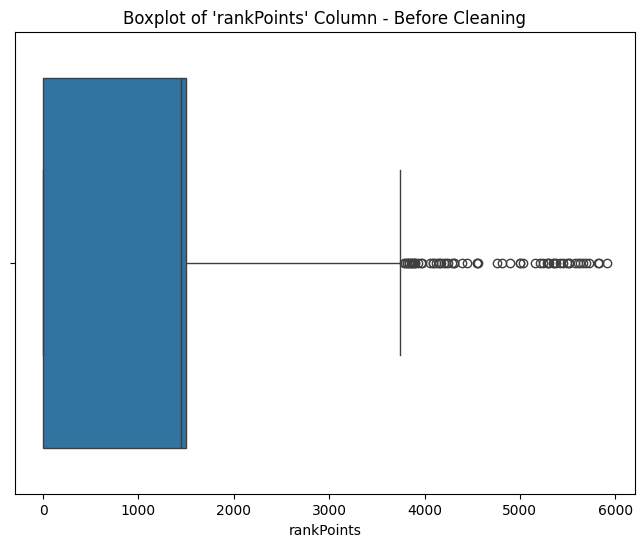

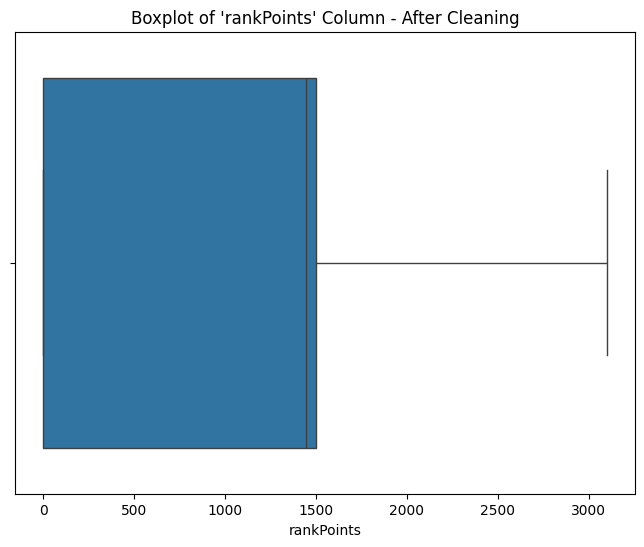

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# Given statistics for "rankPoints" column
mean_rankPoints = 892.0104565674665
stddev_rankPoints = 736.6477793343946
threshold = 3  # Z-score threshold for outliers

# Step 1: Calculate the lower and upper bounds for outliers
lower_bound_rankPoints = mean_rankPoints - (threshold * stddev_rankPoints)
upper_bound_rankPoints = mean_rankPoints + (threshold * stddev_rankPoints)

# Print the calculated bounds
print(f"Lower Bound: {lower_bound_rankPoints}")
print(f"Upper Bound: {upper_bound_rankPoints}")

# Step 2: Filter out rows where "rankPoints" is outside the bounds (outliers)
df_cleaned_rankPoints = df.filter(
    (F.col('rankPoints') >= lower_bound_rankPoints) &
    (F.col('rankPoints') <= upper_bound_rankPoints)
)

# Convert the original "rankPoints" column to Pandas DataFrame for visualization
rankPoints_df = df.select('rankPoints').toPandas()
rankPoints_cleaned_df = df_cleaned_rankPoints.select('rankPoints').toPandas()

# Create a boxplot to visualize the "rankPoints" column before cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=rankPoints_df['rankPoints'])
plt.title("Boxplot of 'rankPoints' Column - Before Cleaning")
plt.show()

# Create a boxplot to visualize the "rankPoints" column after cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=rankPoints_cleaned_df['rankPoints'])
plt.title("Boxplot of 'rankPoints' Column - After Cleaning")
plt.show()


In [61]:
df.describe('rideDistance').show()


+-------+------------------+
|summary|      rideDistance|
+-------+------------------+
|  count|           4446966|
|   mean| 606.1156691540916|
| stddev|1498.3435130715152|
|    min|               0.0|
|    max|           40710.0|
+-------+------------------+



Lower Bound: -3888.9148700604537
Upper Bound: 5101.146208368637


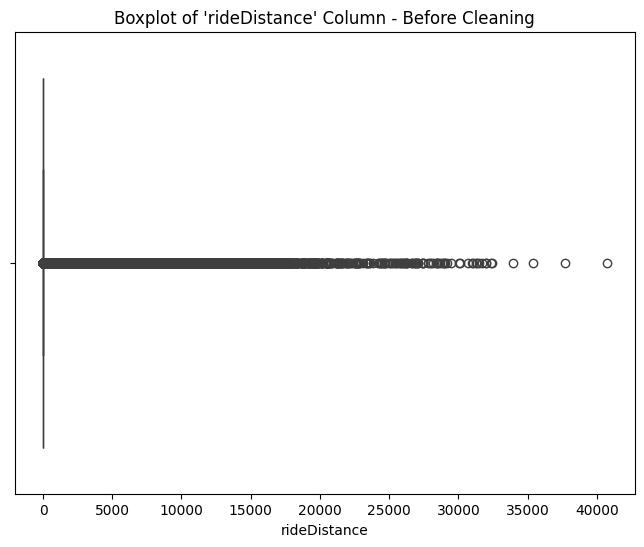

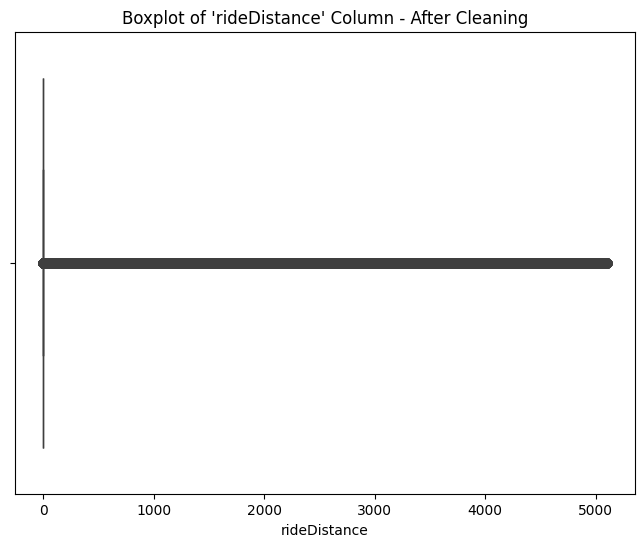

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# Given statistics for "rideDistance" column
mean_rideDistance = 606.1156691540916
stddev_rideDistance = 1498.3435130715152
threshold = 3  # Z-score threshold for outliers

# Step 1: Calculate the lower and upper bounds for outliers
lower_bound_rideDistance = mean_rideDistance - (threshold * stddev_rideDistance)
upper_bound_rideDistance = mean_rideDistance + (threshold * stddev_rideDistance)

# Print the calculated bounds
print(f"Lower Bound: {lower_bound_rideDistance}")
print(f"Upper Bound: {upper_bound_rideDistance}")

# Step 2: Filter out rows where "rideDistance" is outside the bounds (outliers)
df_cleaned_rideDistance = df.filter(
    (F.col('rideDistance') >= lower_bound_rideDistance) &
    (F.col('rideDistance') <= upper_bound_rideDistance)
)

# Convert the original "rideDistance" column to Pandas DataFrame for visualization
rideDistance_df = df.select('rideDistance').toPandas()
rideDistance_cleaned_df = df_cleaned_rideDistance.select('rideDistance').toPandas()

# Create a boxplot to visualize the "rideDistance" column before cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=rideDistance_df['rideDistance'])
plt.title("Boxplot of 'rideDistance' Column - Before Cleaning")
plt.show()

# Create a boxplot to visualize the "rideDistance" column after cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=rideDistance_cleaned_df['rideDistance'])
plt.title("Boxplot of 'rideDistance' Column - After Cleaning")
plt.show()


In [63]:
df.describe('swimDistance').show()


+-------+-----------------+
|summary|     swimDistance|
+-------+-----------------+
|  count|          4446966|
|   mean|4.509322451307245|
| stddev|30.50219918203477|
|    min|              0.0|
|    max|           3823.0|
+-------+-----------------+



Lower Bound: -86.99727509479706
Upper Bound: 96.01591999741154


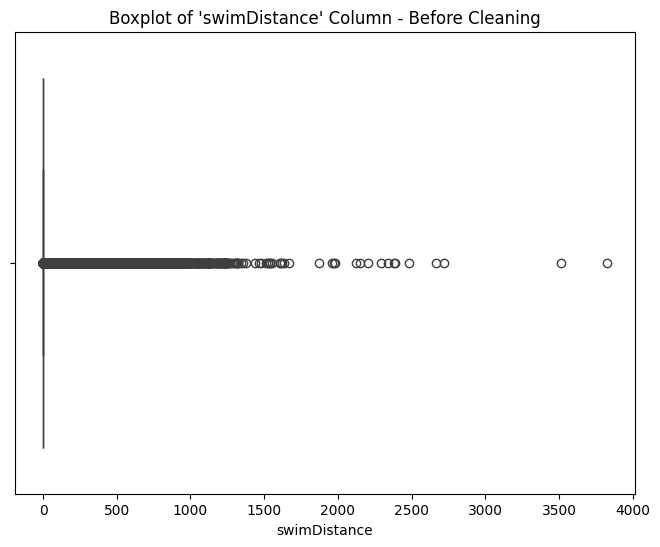

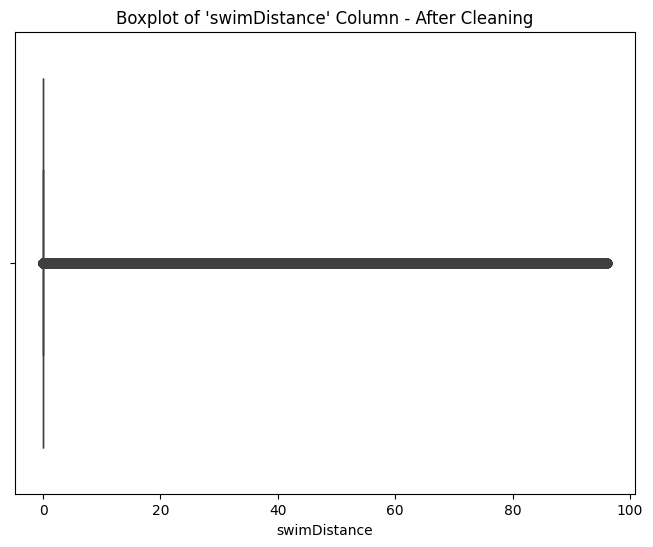

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# Given statistics for "swimDistance" column
mean_swimDistance = 4.509322451307245
stddev_swimDistance = 30.50219918203477
threshold = 3  # Z-score threshold for outliers

# Step 1: Calculate the lower and upper bounds for outliers
lower_bound_swimDistance = mean_swimDistance - (threshold * stddev_swimDistance)
upper_bound_swimDistance = mean_swimDistance + (threshold * stddev_swimDistance)

# Print the calculated bounds
print(f"Lower Bound: {lower_bound_swimDistance}")
print(f"Upper Bound: {upper_bound_swimDistance}")

# Step 2: Filter out rows where "swimDistance" is outside the bounds (outliers)
df_cleaned_swimDistance = df.filter(
    (F.col('swimDistance') >= lower_bound_swimDistance) &
    (F.col('swimDistance') <= upper_bound_swimDistance)
)

# Convert the original "swimDistance" column to Pandas DataFrame for visualization
swimDistance_df = df.select('swimDistance').toPandas()
swimDistance_cleaned_df = df_cleaned_swimDistance.select('swimDistance').toPandas()

# Create a boxplot to visualize the "swimDistance" column before cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=swimDistance_df['swimDistance'])
plt.title("Boxplot of 'swimDistance' Column - Before Cleaning")
plt.show()

# Create a boxplot to visualize the "swimDistance" column after cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=swimDistance_cleaned_df['swimDistance'])
plt.title("Boxplot of 'swimDistance' Column - After Cleaning")
plt.show()


In [65]:
df.describe('walkDistance').show()


+-------+------------------+
|summary|      walkDistance|
+-------+------------------+
|  count|           4446966|
|   mean|1154.2178590962735|
| stddev|1183.4970417898285|
|    min|               0.0|
|    max|           25780.0|
+-------+------------------+



Lower Bound: -2396.273266273212
Upper Bound: 4704.7089844657585


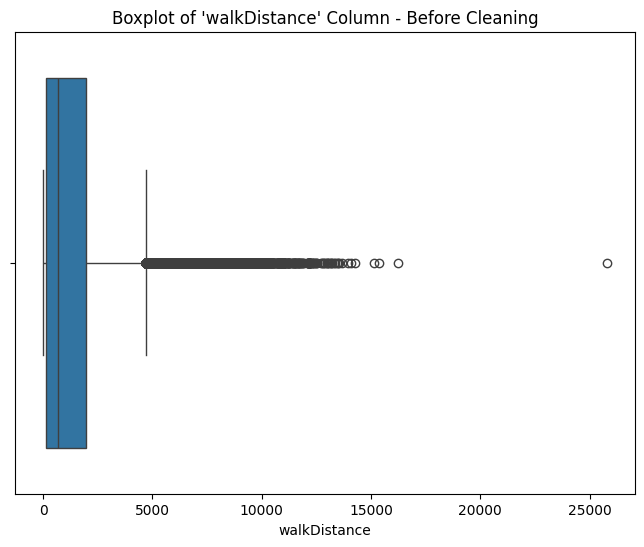

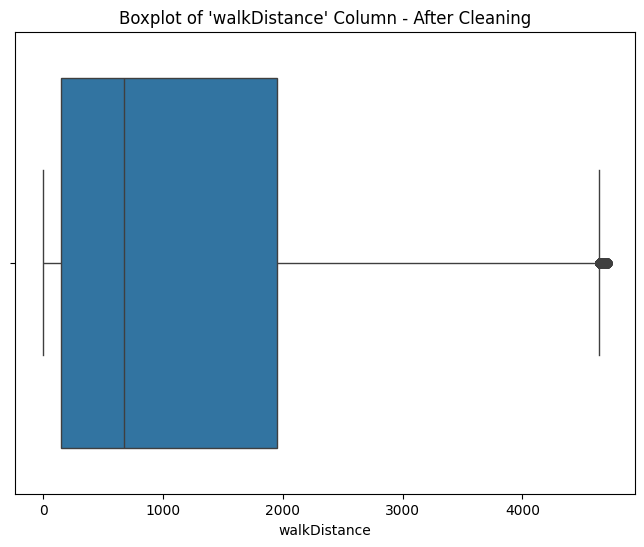

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# Given statistics for "walkDistance" column
mean_walkDistance = 1154.2178590962735
stddev_walkDistance = 1183.4970417898285
threshold = 3  # Z-score threshold for outliers

# Step 1: Calculate the lower and upper bounds for outliers
lower_bound_walkDistance = mean_walkDistance - (threshold * stddev_walkDistance)
upper_bound_walkDistance = mean_walkDistance + (threshold * stddev_walkDistance)

# Print the calculated bounds
print(f"Lower Bound: {lower_bound_walkDistance}")
print(f"Upper Bound: {upper_bound_walkDistance}")

# Step 2: Filter out rows where "walkDistance" is outside the bounds (outliers)
df_cleaned_walkDistance = df.filter(
    (F.col('walkDistance') >= lower_bound_walkDistance) &
    (F.col('walkDistance') <= upper_bound_walkDistance)
)

# Convert the original "walkDistance" column to Pandas DataFrame for visualization
walkDistance_df = df.select('walkDistance').toPandas()
walkDistance_cleaned_df = df_cleaned_walkDistance.select('walkDistance').toPandas()

# Create a boxplot to visualize the "walkDistance" column before cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=walkDistance_df['walkDistance'])
plt.title("Boxplot of 'walkDistance' Column - Before Cleaning")
plt.show()

# Create a boxplot to visualize the "walkDistance" column after cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=walkDistance_cleaned_df['walkDistance'])
plt.title("Boxplot of 'walkDistance' Column - After Cleaning")
plt.show()


In [67]:
df.describe('weaponsAcquired').show()


+-------+------------------+
|summary|   weaponsAcquired|
+-------+------------------+
|  count|           4446966|
|   mean|3.6604876223474614|
| stddev| 2.456543622958438|
|    min|                 0|
|    max|               236|
+-------+------------------+



Lower Bound: -3.7091432465278524
Upper Bound: 11.030118491222776


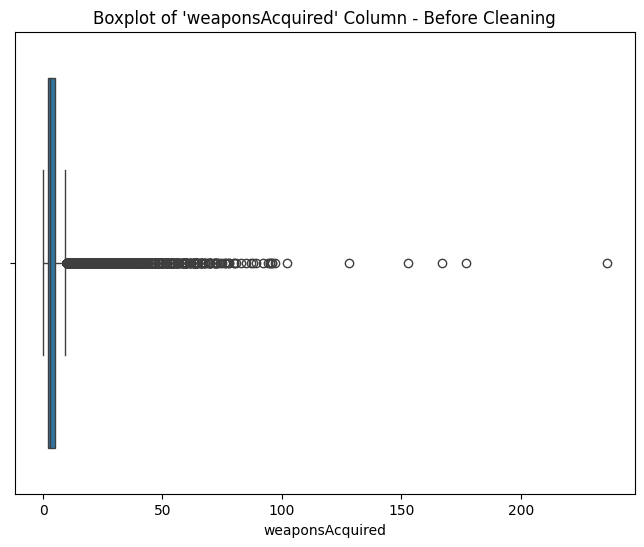

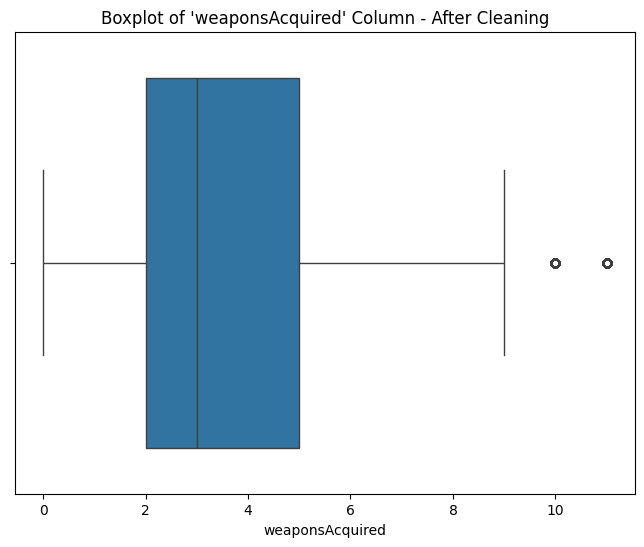

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# Given statistics for "weaponsAcquired" column
mean_weaponsAcquired = 3.6604876223474614
stddev_weaponsAcquired = 2.456543622958438
threshold = 3  # Z-score threshold for outliers

# Step 1: Calculate the lower and upper bounds for outliers
lower_bound_weaponsAcquired = mean_weaponsAcquired - (threshold * stddev_weaponsAcquired)
upper_bound_weaponsAcquired = mean_weaponsAcquired + (threshold * stddev_weaponsAcquired)

# Print the calculated bounds
print(f"Lower Bound: {lower_bound_weaponsAcquired}")
print(f"Upper Bound: {upper_bound_weaponsAcquired}")

# Step 2: Filter out rows where "weaponsAcquired" is outside the bounds (outliers)
df_cleaned_weaponsAcquired = df.filter(
    (F.col('weaponsAcquired') >= lower_bound_weaponsAcquired) &
    (F.col('weaponsAcquired') <= upper_bound_weaponsAcquired)
)

# Convert the original "weaponsAcquired" column to Pandas DataFrame for visualization
weaponsAcquired_df = df.select('weaponsAcquired').toPandas()
weaponsAcquired_cleaned_df = df_cleaned_weaponsAcquired.select('weaponsAcquired').toPandas()

# Create a boxplot to visualize the "weaponsAcquired" column before cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=weaponsAcquired_df['weaponsAcquired'])
plt.title("Boxplot of 'weaponsAcquired' Column - Before Cleaning")
plt.show()

# Create a boxplot to visualize the "weaponsAcquired" column after cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=weaponsAcquired_cleaned_df['weaponsAcquired'])
plt.title("Boxplot of 'weaponsAcquired' Column - After Cleaning")
plt.show()


In [69]:
df.describe('matchType_').show()


+-------+------------------+
|summary|        matchType_|
+-------+------------------+
|  count|           4446966|
|   mean|1.4124011741938212|
| stddev|1.5734687601974313|
|    min|               0.0|
|    max|              15.0|
+-------+------------------+



Lower Bound: -3.308005106398473
Upper Bound: 6.132807454786115


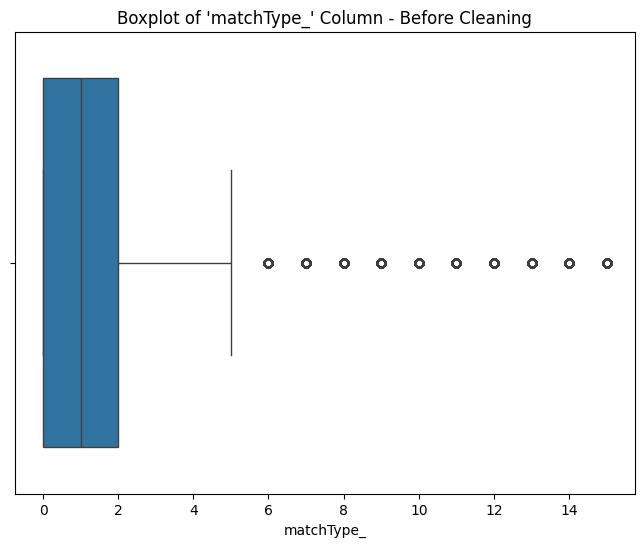

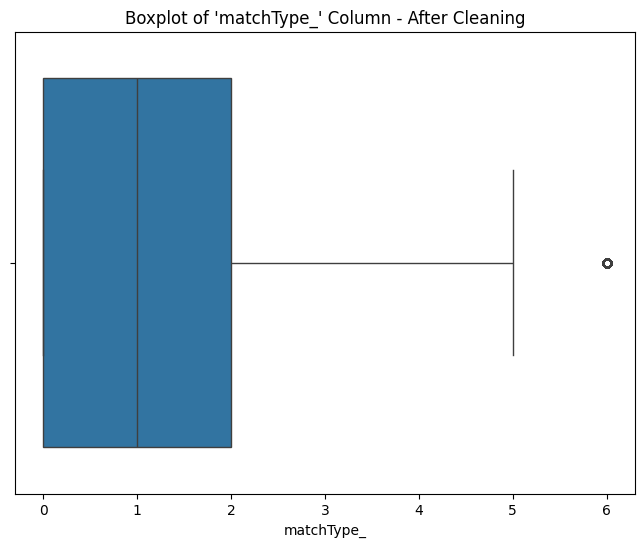

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# Given statistics for "matchType_" column
mean_matchType_ = 1.4124011741938212
stddev_matchType_ = 1.5734687601974313
threshold = 3  # Z-score threshold for outliers

# Step 1: Calculate the lower and upper bounds for outliers
lower_bound_matchType_ = mean_matchType_ - (threshold * stddev_matchType_)
upper_bound_matchType_ = mean_matchType_ + (threshold * stddev_matchType_)

# Print the calculated bounds
print(f"Lower Bound: {lower_bound_matchType_}")
print(f"Upper Bound: {upper_bound_matchType_}")

# Step 2: Filter out rows where "matchType_" is outside the bounds (outliers)
df_cleaned_matchType_ = df.filter(
    (F.col('matchType_') >= lower_bound_matchType_) &
    (F.col('matchType_') <= upper_bound_matchType_)
)

# Convert the original "matchType_" column to Pandas DataFrame for visualization
matchType_df = df.select('matchType_').toPandas()
matchType_cleaned_df = df_cleaned_matchType_.select('matchType_').toPandas()

# Create a boxplot to visualize the "matchType_" column before cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=matchType_df['matchType_'])
plt.title("Boxplot of 'matchType_' Column - Before Cleaning")
plt.show()

# Create a boxplot to visualize the "matchType_" column after cleaning outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=matchType_cleaned_df['matchType_'])
plt.title("Boxplot of 'matchType_' Column - After Cleaning")
plt.show()


In [71]:
df.columns

['Id',
 'groupId',
 'matchId',
 'assists',
 'boosts',
 'damageDealt',
 'DBNOs',
 'headshotKills',
 'heals',
 'killPlace',
 'killPoints',
 'kills',
 'killStreaks',
 'longestKill',
 'matchDuration',
 'matchType',
 'maxPlace',
 'numGroups',
 'rankPoints',
 'revives',
 'rideDistance',
 'roadKills',
 'swimDistance',
 'teamKills',
 'vehicleDestroys',
 'walkDistance',
 'weaponsAcquired',
 'winPoints',
 'winPlacePerc',
 'matchType_']

In [72]:
def robust_scale_multiple_columns(df, columns):

    for col_name in columns:
        # Calculate quartiles and median
        quartiles = df.approxQuantile(col_name, [0.25, 0.5, 0.75], 0.01)
        q1 = quartiles[0]
        median = quartiles[1]
        q3 = quartiles[2]
        iqr = q3 - q1

        # Handle cases where IQR is zero (to avoid division by zero)
        if iqr == 0:
            iqr = 1e-9  # A small value to prevent division by zero

        # Scale the column
        df = df.withColumn(
            col_name + "_scaled",
            (F.col(col_name) - median) / iqr
        )

    return df

In [73]:

columns_to_scale = ['assists',
 'boosts',
 'damageDealt',
 'DBNOs',
 'headshotKills',
 'heals',
 'killPlace',
 'killPoints',
 'kills',
 'killStreaks',
 'longestKill',
 'matchDuration',
 'maxPlace',
 'numGroups',
 'rankPoints',
 'revives',
 'rideDistance',
 'roadKills',
 'swimDistance',
 'walkDistance',
 'weaponsAcquired',
 'winPoints',
 'matchType_']

In [74]:
df = robust_scale_multiple_columns(df, columns_to_scale)


In [75]:
df.columns


['Id',
 'groupId',
 'matchId',
 'assists',
 'boosts',
 'damageDealt',
 'DBNOs',
 'headshotKills',
 'heals',
 'killPlace',
 'killPoints',
 'kills',
 'killStreaks',
 'longestKill',
 'matchDuration',
 'matchType',
 'maxPlace',
 'numGroups',
 'rankPoints',
 'revives',
 'rideDistance',
 'roadKills',
 'swimDistance',
 'teamKills',
 'vehicleDestroys',
 'walkDistance',
 'weaponsAcquired',
 'winPoints',
 'winPlacePerc',
 'matchType_',
 'assists_scaled',
 'boosts_scaled',
 'damageDealt_scaled',
 'DBNOs_scaled',
 'headshotKills_scaled',
 'heals_scaled',
 'killPlace_scaled',
 'killPoints_scaled',
 'kills_scaled',
 'killStreaks_scaled',
 'longestKill_scaled',
 'matchDuration_scaled',
 'maxPlace_scaled',
 'numGroups_scaled',
 'rankPoints_scaled',
 'revives_scaled',
 'rideDistance_scaled',
 'roadKills_scaled',
 'swimDistance_scaled',
 'walkDistance_scaled',
 'weaponsAcquired_scaled',
 'winPoints_scaled',
 'matchType__scaled']

In [76]:
df=df.drop('assists',
 'boosts',
 'damageDealt',
 'DBNOs',
 'headshotKills',
 'heals',
 'killPlace',
 'killPoints',
 'kills',
 'killStreaks',
 'longestKill',
 'matchDuration',
 'maxPlace',
 'numGroups',
 'rankPoints',
 'revives',
 'rideDistance',
 'roadKills',
 'swimDistance',
 'walkDistance',
 'weaponsAcquired',
 'winPoints', 'matchType_')

In [77]:
df.show()

+--------------+--------------+--------------+---------+---------+---------------+------------+-------------------+-------------+--------------------+------------+--------------------+------------+--------------------+------------------+------------+------------------+-------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+----------------+--------------------+--------------------+----------------------+------------------+-----------------+
|            Id|       groupId|       matchId|matchType|teamKills|vehicleDestroys|winPlacePerc|     assists_scaled|boosts_scaled|  damageDealt_scaled|DBNOs_scaled|headshotKills_scaled|heals_scaled|    killPlace_scaled| killPoints_scaled|kills_scaled|killStreaks_scaled| longestKill_scaled|matchDuration_scaled|     maxPlace_scaled|    numGroups_scaled|   rankPoints_scaled|     revives_scaled| rideDistance_scaled|roadKills_scaled| swimDistance_scaled| walkDistance_

In [78]:
df=df.drop('matchId','groupId','Id')

In [79]:
df.show()

+---------+---------+---------------+------------+-------------------+-------------+--------------------+------------+--------------------+------------+--------------------+------------------+------------+------------------+-------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+----------------+--------------------+--------------------+----------------------+------------------+-----------------+
|matchType|teamKills|vehicleDestroys|winPlacePerc|     assists_scaled|boosts_scaled|  damageDealt_scaled|DBNOs_scaled|headshotKills_scaled|heals_scaled|    killPlace_scaled| killPoints_scaled|kills_scaled|killStreaks_scaled| longestKill_scaled|matchDuration_scaled|     maxPlace_scaled|    numGroups_scaled|   rankPoints_scaled|     revives_scaled| rideDistance_scaled|roadKills_scaled| swimDistance_scaled| walkDistance_scaled|weaponsAcquired_scaled|  winPoints_scaled|matchType__scaled|
+---------+---------+-

In [80]:
df.columns


['matchType',
 'teamKills',
 'vehicleDestroys',
 'winPlacePerc',
 'assists_scaled',
 'boosts_scaled',
 'damageDealt_scaled',
 'DBNOs_scaled',
 'headshotKills_scaled',
 'heals_scaled',
 'killPlace_scaled',
 'killPoints_scaled',
 'kills_scaled',
 'killStreaks_scaled',
 'longestKill_scaled',
 'matchDuration_scaled',
 'maxPlace_scaled',
 'numGroups_scaled',
 'rankPoints_scaled',
 'revives_scaled',
 'rideDistance_scaled',
 'roadKills_scaled',
 'swimDistance_scaled',
 'walkDistance_scaled',
 'weaponsAcquired_scaled',
 'winPoints_scaled',
 'matchType__scaled']

In [81]:
from pyspark.ml.feature import VectorAssembler
featureassembler=VectorAssembler(inputCols=['assists_scaled','boosts_scaled','damageDealt_scaled','DBNOs_scaled','headshotKills_scaled','heals_scaled', 'killPlace_scaled', 'killPoints_scaled', 'kills_scaled',
 'killStreaks_scaled',
 'longestKill_scaled',
 'matchDuration_scaled',
 'maxPlace_scaled',
 'numGroups_scaled',
 'rankPoints_scaled',
 'revives_scaled',
 'rideDistance_scaled',
 'roadKills_scaled',
 'swimDistance_scaled',
 'walkDistance_scaled',
 'weaponsAcquired_scaled',
 'winPoints_scaled',
 'matchType__scaled']
                          ,outputCol="Independent Features")
output=featureassembler.transform(df)


In [82]:
output.select('Independent Features').show()


+--------------------+
|Independent Features|
+--------------------+
|(23,[2,6,7,11,12,...|
|(23,[2,6,11,12,13...|
|(23,[0,2,6,11,12,...|
|(23,[2,6,11,12,14...|
|(23,[2,6,8,9,10,1...|
|(23,[2,3,4,6,8,9,...|
|(23,[2,6,7,11,12,...|
|(23,[2,7,11,14,16...|
|(23,[2,6,11,12,13...|
|(23,[2,6,11,12,13...|
|(23,[2,6,11,12,13...|
|(23,[2,3,6,11,12,...|
|(23,[2,6,11,12,13...|
|[0.0,0.5,1.303297...|
|[0.0,0.5,0.214648...|
|(23,[2,3,6,11,12,...|
|[0.0,1.0,-0.00745...|
|(23,[1,2,5,6,8,9,...|
|(23,[2,6,11,12,13...|
|(23,[1,2,5,7,11,1...|
+--------------------+
only showing top 20 rows



In [83]:
output.show()


+---------+---------+---------------+------------+-------------------+-------------+--------------------+------------+--------------------+------------+--------------------+------------------+------------+------------------+-------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+----------------+--------------------+--------------------+----------------------+------------------+-----------------+--------------------+
|matchType|teamKills|vehicleDestroys|winPlacePerc|     assists_scaled|boosts_scaled|  damageDealt_scaled|DBNOs_scaled|headshotKills_scaled|heals_scaled|    killPlace_scaled| killPoints_scaled|kills_scaled|killStreaks_scaled| longestKill_scaled|matchDuration_scaled|     maxPlace_scaled|    numGroups_scaled|   rankPoints_scaled|     revives_scaled| rideDistance_scaled|roadKills_scaled| swimDistance_scaled| walkDistance_scaled|weaponsAcquired_scaled|  winPoints_scaled|matchType__scaled|In

In [84]:
df=df.drop('matchType')

In [85]:
finalized_data=output.select("Independent Features","winPlacePerc")


In [86]:
finalized_data.show()


+--------------------+------------+
|Independent Features|winPlacePerc|
+--------------------+------------+
|(23,[2,6,7,11,12,...|      0.4444|
|(23,[2,6,11,12,13...|        0.64|
|(23,[0,2,6,11,12,...|      0.7755|
|(23,[2,6,11,12,14...|      0.1667|
|(23,[2,6,8,9,10,1...|      0.1875|
|(23,[2,3,4,6,8,9,...|       0.037|
|(23,[2,6,7,11,12,...|         0.0|
|(23,[2,7,11,14,16...|      0.7368|
|(23,[2,6,11,12,13...|      0.3704|
|(23,[2,6,11,12,13...|      0.2143|
|(23,[2,6,11,12,13...|      0.3929|
|(23,[2,3,6,11,12,...|      0.4043|
|(23,[2,6,11,12,13...|      0.9286|
|[0.0,0.5,1.303297...|       0.875|
|[0.0,0.5,0.214648...|         0.9|
|(23,[2,3,6,11,12,...|      0.2766|
|[0.0,1.0,-0.00745...|      0.7308|
|(23,[1,2,5,6,8,9,...|      0.8211|
|(23,[2,6,11,12,13...|      0.1923|
|(23,[1,2,5,7,11,1...|       0.931|
+--------------------+------------+
only showing top 20 rows



In [87]:
from pyspark.ml.regression import GBTRegressor
train_data, test_data = finalized_data.randomSplit([0.75, 0.25], seed=42)
gbt = GBTRegressor(featuresCol='Independent Features', labelCol='winPlacePerc')
model = gbt.fit(train_data)


In [88]:
pred_results=model.transform(test_data)


In [96]:
 #Define Evaluation Metrics
 from pyspark.ml.evaluation import RegressionEvaluator
 from pyspark.sql.functions import col, abs, avg, sqrt
metrics = ["rmse", "mse", "mae", "r2"]
for metric in metrics:
    evaluator = RegressionEvaluator(labelCol="winPlacePerc", predictionCol="prediction", metricName=metric)
    score = evaluator.evaluate(pred_results)
    print(f"{metric.upper()}: {score:.4f}")

# Compute MAPE (Mean Absolute Percentage Error)
mape_df = pred_results.withColumn("error", abs(col("winPlacePerc") - col("prediction")) / col("winPlacePerc"))
mape_score = mape_df.select(avg(col("error")) * 100).collect()[0][0]
print(f"MAPE: {mape_score:.2f}%")


RMSE: 0.1004
MSE: 0.0101
MAE: 0.0727
R2: 0.8933
MAPE: 26.92%


In [ ]:
#spark.stop